In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("/content/Group 2 Job 1_2_3 _ Breast Cancer Dataset.csv")
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
df.shape

(569, 32)

In [4]:
df.columns

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

In [6]:
df.describe()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
x.radius_mean,0
x.texture_mean,0
x.perimeter_mean,0
x.area_mean,0
x.smoothness_mean,0
x.compactness_mean,0
x.concavity_mean,0
x.concave_pts_mean,0
x.symmetry_mean,0


In [8]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [9]:
df['y'] = df['y'].map({'M':1, 'B':0})

In [10]:
df.fillna(df.mean(), inplace=True)

<Axes: >

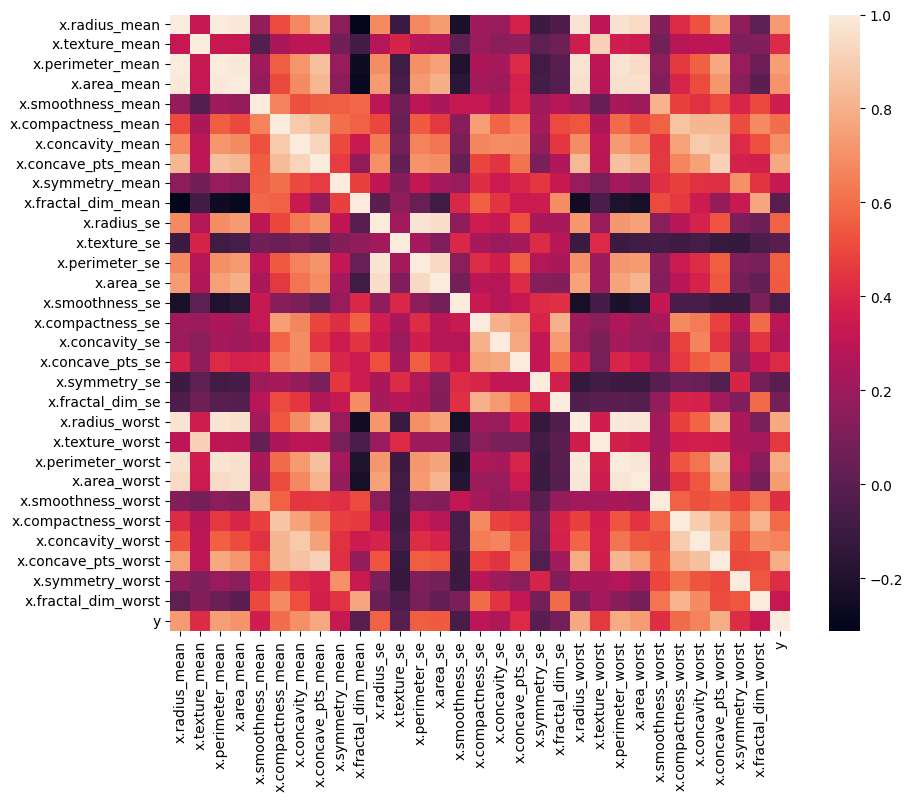

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)

In [12]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
print("\n--- Model Performance After Scaling ---")
model_scaled = LogisticRegression()
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy (after scaling):", accuracy_score(y_test, y_pred_scaled))
print("Classification Report (after scaling):\n", classification_report(y_test, y_pred_scaled))

print("\n--- Model Performance Before Scaling (for comparison) ---")
print("Accuracy (before scaling):", accuracy_score(y_test, y_pred))
print("Classification Report (before scaling):\n", classification_report(y_test, y_pred))


--- Model Performance After Scaling ---
Accuracy (after scaling): 0.9912280701754386
Classification Report (after scaling):
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        77
           1       0.97      1.00      0.99        37

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114


--- Model Performance Before Scaling (for comparison) ---
Accuracy (before scaling): 0.9122807017543859
Classification Report (before scaling):
               precision    recall  f1-score   support

           0       0.95      0.92      0.93        77
           1       0.85      0.89      0.87        37

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.90       114
weighted avg       0.91      0.91      0.91       114



In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("\n--- Decision Tree Classifier ---")
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_scaled, y_train)
y_pred_dtc = dtc.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_dtc))
print("Classification Report:\n", classification_report(y_test, y_pred_dtc))

print("\n--- Random Forest Classifier ---")
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_scaled, y_train)
y_pred_rfc = rfc.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("Classification Report:\n", classification_report(y_test, y_pred_rfc))

print("\n--- Support Vector Machine (SVM) ---")
svc = SVC(random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Classification Report:\n", classification_report(y_test, y_pred_svc))


--- Decision Tree Classifier ---
Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        77
           1       0.92      0.92      0.92        37

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Random Forest Classifier ---
Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        77
           1       0.92      0.92      0.92        37

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Support Vector Machine (SVM) ---
Accuracy: 0.9824561403508771
Classification Report:
               precision    recall  f1-score   support

           0       0.97   

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9122807017543859
              precision    recall  f1-score   support

           0       0.95      0.92      0.93        77
           1       0.85      0.89      0.87        37

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.90       114
weighted avg       0.91      0.91      0.91       114



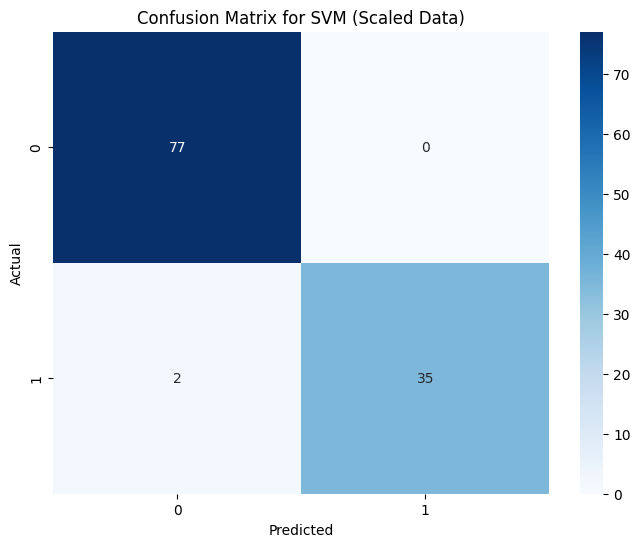

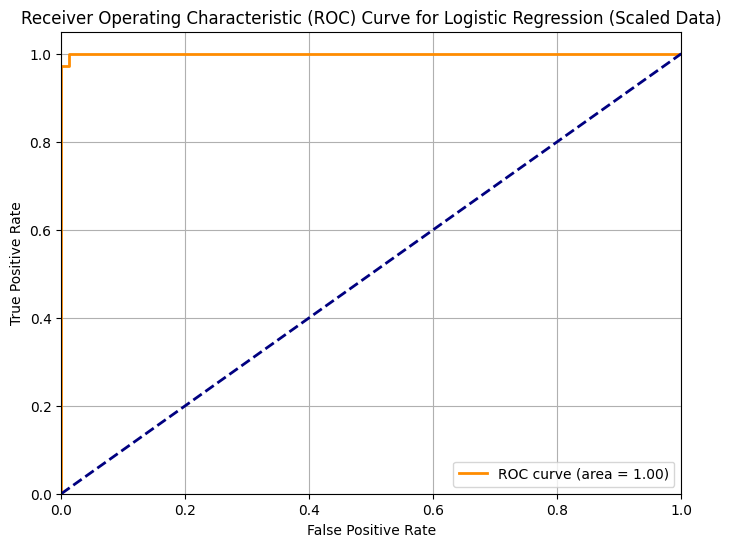

In [20]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Confusion Matrix and Heatmap for the best performing model (SVM)
cm_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for SVM (Scaled Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve for Logistic Regression (scaled data)
# Make sure the model can predict probabilities. If not, retrain with probability=True for SVC or use a model like Logistic Regression that provides it by default.
y_scores_lr = model_scaled.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression (Scaled Data)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [23]:
print("\n--- Overfitting/Underfitting Analysis ---")

# Logistic Regression (Scaled)
y_train_pred_scaled_lr = model_scaled.predict(X_train_scaled)
lr_train_acc = accuracy_score(y_train, y_train_pred_scaled_lr)
lr_test_acc = accuracy_score(y_test, y_pred_scaled)
print("Logistic Regression (Scaled) - Training Accuracy:", lr_train_acc)
print("Logistic Regression (Scaled) - Test Accuracy:", lr_test_acc)
if abs(lr_train_acc - lr_test_acc) < 0.02 and lr_test_acc > 0.8:
    print("Status: Well-fitted model")
elif lr_train_acc > lr_test_acc and lr_train_acc - lr_test_acc > 0.05:
    print("Status: Overfitting")
else:
    print("Status: Underfitting or Poor performance")

# Decision Tree Classifier
y_train_pred_dtc = dtc.predict(X_train_scaled)
dtc_train_acc = accuracy_score(y_train, y_train_pred_dtc)
dtc_test_acc = accuracy_score(y_test, y_pred_dtc)
print("\nDecision Tree Classifier - Training Accuracy:", dtc_train_acc)
print("Decision Tree Classifier - Test Accuracy:", dtc_test_acc)
if abs(dtc_train_acc - dtc_test_acc) < 0.02 and dtc_test_acc > 0.8:
    print("Status: Well-fitted model")
elif dtc_train_acc > dtc_test_acc and dtc_train_acc - dtc_test_acc > 0.05:
    print("Status: Overfitting")
else:
    print("Status: Underfitting or Poor performance")

# Random Forest Classifier
y_train_pred_rfc = rfc.predict(X_train_scaled)
rfc_train_acc = accuracy_score(y_train, y_train_pred_rfc)
rfc_test_acc = accuracy_score(y_test, y_pred_rfc)
print("\nRandom Forest Classifier - Training Accuracy:", rfc_train_acc)
print("Random Forest Classifier - Test Accuracy:", rfc_test_acc)
if abs(rfc_train_acc - rfc_test_acc) < 0.02 and rfc_test_acc > 0.8:
    print("Status: Well-fitted model")
elif rfc_train_acc > rfc_test_acc and rfc_train_acc - rfc_test_acc > 0.05:
    print("Status: Overfitting")
else:
    print("Status: Underfitting or Poor performance")

# Support Vector Machine (SVM)
y_train_pred_svc = svc.predict(X_train_scaled)
svc_train_acc = accuracy_score(y_train, y_train_pred_svc)
svc_test_acc = accuracy_score(y_test, y_pred_svc)
print("\nSupport Vector Machine (SVM) - Training Accuracy:", svc_train_acc)
print("Support Vector Machine (SVM) - Test Accuracy:", svc_test_acc)
if abs(svc_train_acc - svc_test_acc) < 0.02 and svc_test_acc > 0.8:
    print("Status: Well-fitted model")
elif svc_train_acc > svc_test_acc and svc_train_acc - svc_test_acc > 0.05:
    print("Status: Overfitting")
else:
    print("Status: Underfitting or Poor performance")


--- Overfitting/Underfitting Analysis ---
Logistic Regression (Scaled) - Training Accuracy: 0.9868131868131869
Logistic Regression (Scaled) - Test Accuracy: 0.9912280701754386
Status: Well-fitted model

Decision Tree Classifier - Training Accuracy: 1.0
Decision Tree Classifier - Test Accuracy: 0.9473684210526315
Status: Overfitting

Random Forest Classifier - Training Accuracy: 1.0
Random Forest Classifier - Test Accuracy: 0.9473684210526315
Status: Overfitting

Support Vector Machine (SVM) - Training Accuracy: 0.9868131868131869
Support Vector Machine (SVM) - Test Accuracy: 0.9824561403508771
Status: Well-fitted model


In [24]:
from sklearn.model_selection import GridSearchCV

print("\n--- Hyperparameter Tuning for Logistic Regression (Scaled) ---")

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500]
}

# Initialize Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Evaluate the tuned model on the test set
best_lr_model = grid_search.best_estimator_
y_pred_tuned_lr = best_lr_model.predict(X_test_scaled)

print("\nAccuracy of Tuned Logistic Regression:", accuracy_score(y_test, y_pred_tuned_lr))
print("Classification Report of Tuned Logistic Regression:\n", classification_report(y_test, y_pred_tuned_lr))


--- Hyperparameter Tuning for Logistic Regression (Scaled) ---
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.9802197802197803

Accuracy of Tuned Logistic Regression: 0.9912280701754386
Classification Report of Tuned Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        77
           1       0.97      1.00      0.99        37

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [25]:
import joblib
joblib.dump(model, "breast_cancer_model.pkl")

joblib.dump(best_lr_model, "breast_cancer_model.joblib")

['breast_cancer_model.joblib']